# I. Installation des librairies

Installation des packages à partir de fichier `requirements.txt`

In [1]:
# Manipulation des données
import math
import numpy as np
import pandas as pd

# Visualitation
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import lineStyles
from sympy.physics.units import radian


plt.rcParams['legend.loc'] = 'upper right'
plt.rcParams['grid.color'] = 'b0b0b0'
plt.rcParams['grid.alpha'] = 0.75
plt.rcParams['text.usetex'] = False


# Modèles de régression
import sklearn
from IPython.core.pylabtools import figsize
from matplotlib.pyplot import figure
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Vérification des résultats de sklearn
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
import cvxopt

# Répertoire de travail et gestion d'erreur
import os
import warnings
import typing
import mypy

# Fichier python contenant les fonctions
import frenezik

# III. Définition du repertoire de travail

In [2]:
# Définition du repertoire de travail
chemin = r"C:\Users\lajoi\Documents\1_PROGRAMME DE TRAVAIL\PROGRAMMATION\SimulationRidgeLasso"
mkdir_data = "2_results_data"
mkdir_graphics = "2_results_graphiques"

# Création des dossiers
try :
    # Définir le repertoire de travail
    os.chdir(chemin)

    # Création du dossier pour les graphiques
    os.mkdir(mkdir_data)

    # Création du dossier pour les bases de données
    os.mkdir(mkdir_graphics)

except FileExistsError:
    print("L'un des dossiers existe déjà")

L'un des dossiers existe déjà


# IV. Simulation des données

## IV.1 Simulation Residus

In [3]:
# Taille de la population
PopulationSize = 1000

# Noyau de reprdductibilité
RandomSeed = 1980

# Instanciation de la classe <<Residuals>>
Resid = frenezik.Residuals(population_size=PopulationSize, random_seed=RandomSeed)

# Paramètre de la loi Moyenne
LawMean = 7

# Paramètre de la variance
LawVar = 2

# Fonction pour simuler les residus
Residus = Resid.Simulation(law="normal", law_parameters=[LawMean, LawVar])
Residus

array([ 5.52034528,  8.79787132,  7.16253837,  7.73009619,  5.65246832,
        7.57600471,  6.19107993,  5.38312035,  5.63687748,  7.11970719,
        5.11012274,  2.72696512,  8.51036375, 10.33287756, 10.54241691,
        4.031549  ,  9.52930308,  8.53025596,  9.51752007,  5.27850702,
        8.66730935,  9.37309935,  3.35938532,  6.43531447,  6.71565554,
        5.36565353,  5.53531637,  6.97536557,  6.07066572,  8.72958357,
        6.63385596,  8.10554378, 10.97150212,  8.37965585, 10.10840293,
        6.31217009,  4.81907067, 11.34932353,  4.81844707,  4.46511068,
        6.9297437 ,  5.79131066, 11.32477399,  8.70690619,  6.05807797,
        4.26489076,  5.48180397,  5.68212322, 12.66610509,  7.67822256,
        9.54144339,  5.54209325,  7.81207011,  6.49243688,  6.44384284,
        5.43757589,  5.73377058,  8.68449857,  7.43652854,  5.98797454,
        8.74409161, 10.49476717,  7.67058298,  6.89402516,  3.36135692,
        6.75311306,  5.39401793,  9.48692949,  5.17629344,  6.14

## VI.2 Statistiques Descriptives des residus Simulées

In [4]:
Resid.Statistics(residuals_simulated=Residus, digits=3)

,Name,Value
0,Count,1000.000
1,Mean,6.993
2,Variance,3.873
3,Q25,5.650
4,Q50,6.885
5,Q75,8.335
6,Min,1.688
7,Max,13.094
8,Skewness,0.097
9,Kurtosis,-0.212


## VI.2 Visualisation des residus Simulées

[]

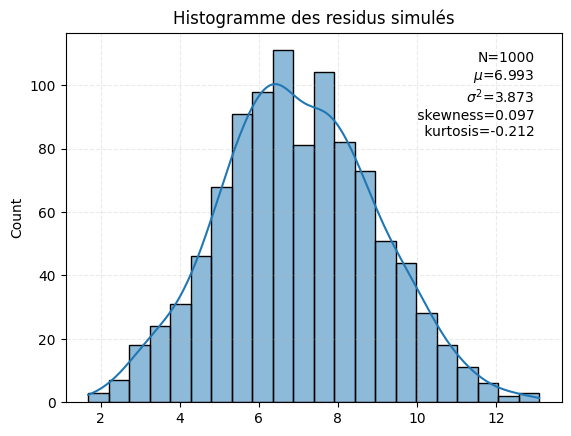

In [5]:
# Fonction pour analyser les residus à partir d'un histogramme
Resid.Visualization(residuals_simulated=Residus, figure="histogram")

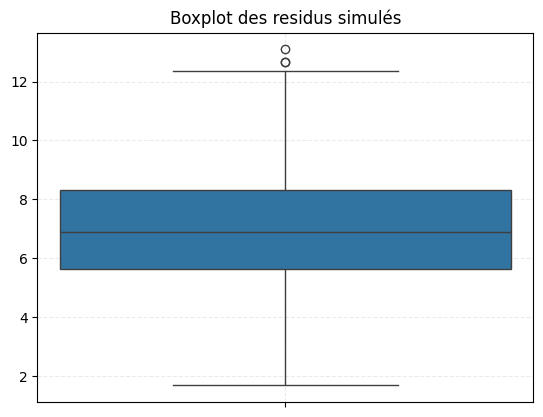

In [6]:
# Fonction pour analyser les residus à partir d'un boxplot
Resid.Visualization(residuals_simulated=Residus, figure="boxplot")

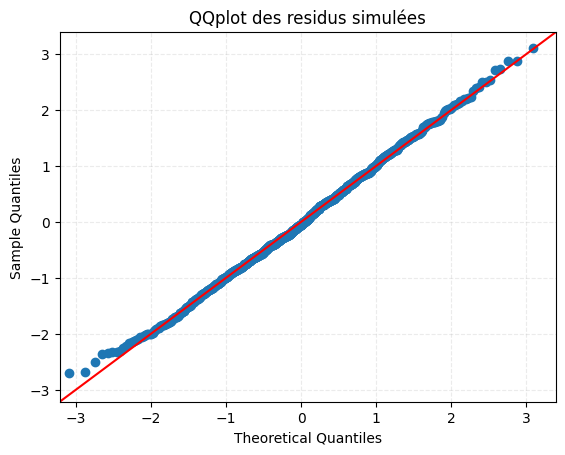

In [7]:
# Fonction pour analyser les residus à partir d'un qqplot
Resid.Visualization(residuals_simulated=Residus, figure="qqplot")

## IV.3 Simulation des données de la population

In [8]:
# Nombre de Variables d'entrée
TrueCoefficients = [0.69, 1.41, 2.73, -2.84, -3, 3.14, -7, 11]

# Fonction pour simuler les variables d'entrée X et la variable cible y
TarPred = frenezik.TargetPredictors(population_size=PopulationSize, true_coefficients=TrueCoefficients)
data_population = TarPred.Simulation(residuals_simulated=Residus)
data_population.head(5)

,y,X_1,X_2,X_3,X_4,X_5,X_6,X_7,X_8
0,21.052563,0.164438,0.751379,0.559667,0.622086,0.352544,0.288917,-0.625688,0.942614
1,25.933064,-0.443863,0.893795,0.932571,0.600834,0.570685,1.048059,0.054178,1.285641
2,20.150914,0.318354,0.935346,-1.505302,0.824108,-0.462144,1.729466,-0.026833,0.990457
3,3.480746,-0.488332,0.386802,1.032594,0.482509,1.082836,1.809636,1.992859,0.509983
4,16.713677,0.471960,0.479903,1.551183,0.574555,0.722288,0.217176,0.446073,1.096668


<Figure size 800x600 with 0 Axes>

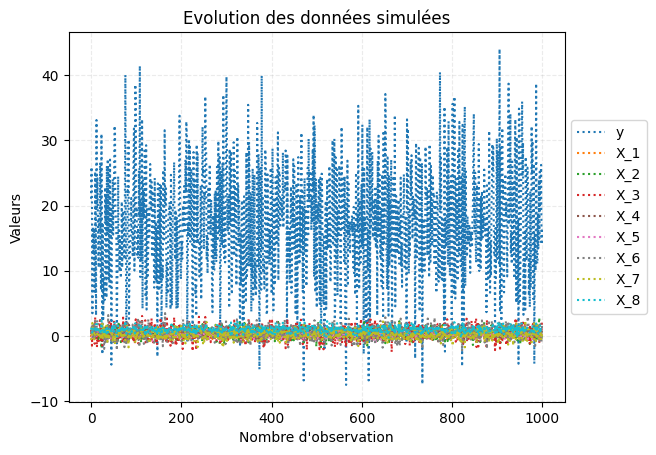

In [9]:
# Lineplot des données issues de la population
plt.figure(figsize=(8,6))
TarPred.Visualization(data_simulated=data_population, figure='lineplot')

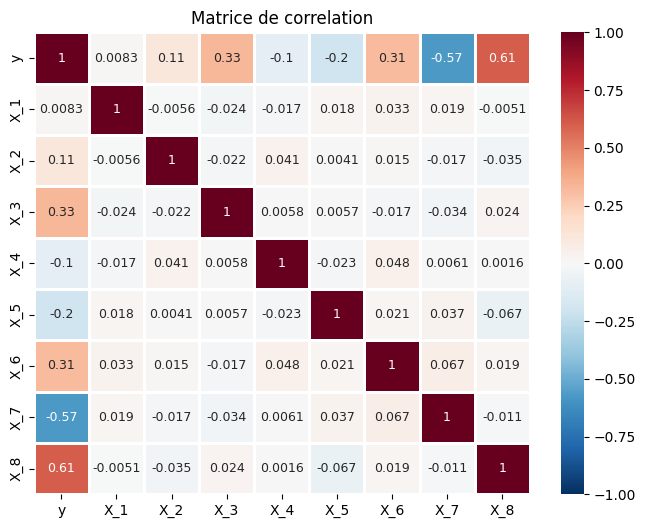

In [10]:
# Matrice de correlation des données issues de la population
plt.figure(figsize=(8,6))
TarPred.Visualization(data_simulated=data_population, figure='correlation_matrix')

## IV.4 Simulation des données de l'échantillon

In [11]:
# Taille de l'échantillon souhaitée
SampleSize = 100

# Fonction pour constituer un échantillon à partir des données de la population
data_sample = TarPred.Sampling(population_simulated=data_population, sample_size=SampleSize)
data_sample.head(5)

,y,X_1,X_2,X_3,X_4,X_5,X_6,X_7,X_8
877,23.118816,0.136878,1.711812,2.461646,1.314192,0.064417,-1.950464,-0.175159,1.417990
987,19.082167,0.309201,-0.480946,0.672805,0.957783,0.651303,1.214577,0.126559,0.929954
649,14.278600,0.679460,-0.223136,1.451145,0.311297,0.448746,1.063908,0.753306,0.565206
783,35.184321,0.281133,0.292337,2.259379,0.507051,0.206710,0.573364,-0.147854,1.714874
712,14.861097,-0.038782,-0.978098,0.362322,0.601105,-0.139506,-0.090091,0.340076,1.193517


<Figure size 800x600 with 0 Axes>

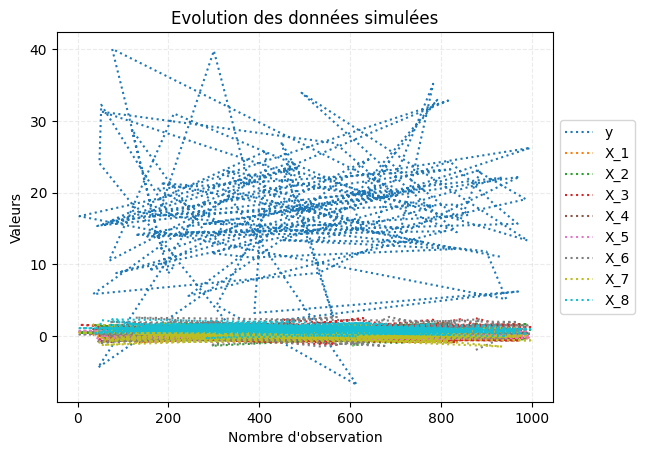

In [12]:
# Lineplot des données issues de l'échantillon
plt.figure(figsize=(8,6))
TarPred.Visualization(data_simulated=data_sample, figure='lineplot')

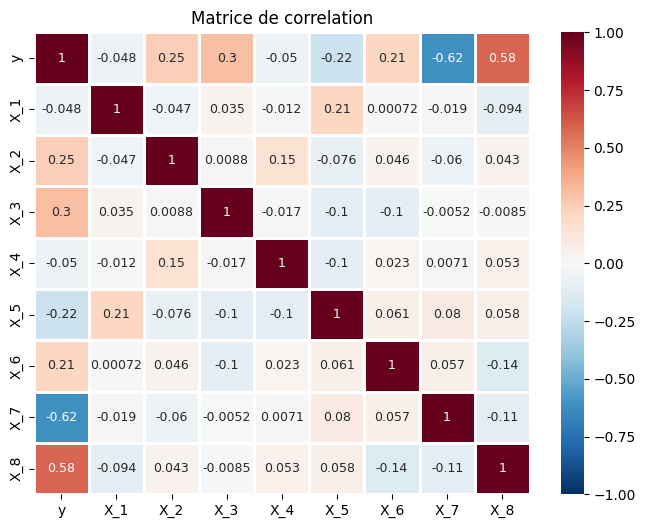

In [13]:
# Matrice de correlation des données issues de l'échantillon
plt.figure(figsize=(8,6))
TarPred.Visualization(data_simulated=data_sample, figure='correlation_matrix')

In [14]:
# Sauvegarde des données d'entrainement et des données d'évaluation
data_population.to_csv(f'{mkdir_data}/data_population.csv', index = False)
data_sample.to_csv(f'{mkdir_data}/data_sample.csv', index = False)

In [15]:
# Choix de la base de donnée de l'étude
data_names = ['data_population', 'data_sample']

# Base de dnnées de l'étude
data_final = pd.read_csv(f"{mkdir_data}/{data_names[0]}.csv")

# Aperçu de la base de données
data_final.head(5)

,y,X_1,X_2,X_3,X_4,X_5,X_6,X_7,X_8
0,21.052563,0.164438,0.751379,0.559667,0.622086,0.352544,0.288917,-0.625688,0.942614
1,25.933064,-0.443863,0.893795,0.932571,0.600834,0.570685,1.048059,0.054178,1.285641
2,20.150914,0.318354,0.935346,-1.505302,0.824108,-0.462144,1.729466,-0.026833,0.990457
3,3.480746,-0.488332,0.386802,1.032594,0.482509,1.082836,1.809636,1.992859,0.509983
4,16.713677,0.471960,0.479903,1.551183,0.574555,0.722288,0.217176,0.446073,1.096668


In [16]:
# Base d'apprentissage et d'évaluation à l'aide de la validation croissée
data_train, data_test = train_test_split(data_final, test_size=0.25, random_state=RandomSeed)

In [18]:
# Variable à prédire
Target = np.array(data_final['y']).reshape(-1,1)

# Variables prédictives
Predictors = data_final.drop('y', axis=1)

# Variables prédictives standardisées : Ridge et Lasso
scaler = StandardScaler()
Predictors_scaled_array = scaler.fit_transform(Predictors)
Predictors_scaled = pd.DataFrame(Predictors_scaled_array, columns=Predictors.columns)

# V. Régression MCO

## 5.1 Estimation

In [19]:
# Estimation du modèle de Régression par MCO avec constante
RegMCO = LinearRegression(fit_intercept=True)
RegMCO.fit(Predictors, Target)

LinearRegression()

## 5.2 Résultats


In [20]:
# Résultats du modèle de régression par MCO
print(RegMCO.coef_)
print('---')
print(TrueCoefficients)

[[ 0.50758207  1.53350028  2.75407517 -2.75977208 -3.30730004  3.16714507
  -6.98699395 10.88956826]]
---
[0.69, 1.41, 2.73, -2.84, -3, 3.14, -7, 11]


In [21]:
# Estimation du modèle de Régression par MCO avec constante
RegressionsModels = OLS(Target, sm.add_constant(Predictors)) # MCO avec X non standardisés et Intercept
regMC0_sm = RegressionsModels.fit()

# Résultats du modèle de régression par MCO
regMC0_sm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.946
Model:                            OLS   Adj. R-squared:                  0.946
Method:                 Least Squares   F-statistic:                     2178.
Date:                Fri, 27 Mar 2026   Prob (F-statistic):               0.00
Time:                        20:34:48   Log-Likelihood:                -2092.0
No. Observations:                1000   AIC:                             4202.
Df Residuals:                     991   BIC:                             4246.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          7.0918      0.198     35.739      0.000       6.702       7.481
X_1            0.5076      0.193      2.626      0.009       0.128       0.887
X_2            1.5335      0.088     17.356      0.000       1.360       1.707
X_3            2.7541      0.066     41.662      0.000       2.624       2.884
X_4           -2.7598      0.162    -16.989      0.000      -3.079      -2.441
X_5           -3.3073      0.158    -20.915      0.000      -3.618      -2.997
X_6            3.1671      0.066     47.672      0.000       3.037       3.298
X_7           -6.9870      0.091    -76.931      0.000      -7.165      -6.809
X_8           10.8896      0.139     78.410      0.000      10.617      11.162
==============================================================================
Omnibus:                        2.505   Durbin-Watson:                   1.989
Prob(Omnibus):                  0.286   Jarque-Bera (JB):                2.432
Skew:                           0.076   Prob(JB):                        0.296
Kurtosis:                       2.812   Cond. No.                         7.31
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

# VI.Paramètres de la Régression Régularisée RIDGE & LASSO

In [22]:
AlphaList = np.linspace(0, 9, 19)
AlphaList

array([0. , 0.5, 1. , 1.5, 2. , 2.5, 3. , 3.5, 4. , 4.5, 5. , 5.5, 6. ,
       6.5, 7. , 7.5, 8. , 8.5, 9. ])

# VII. Régression Régularisée RIDGE

In [30]:
data_population.head(5)

,y,X_1,X_2,X_3,X_4,X_5,X_6,X_7,X_8
0,21.052563,0.164438,0.751379,0.559667,0.622086,0.352544,0.288917,-0.625688,0.942614
1,25.933064,-0.443863,0.893795,0.932571,0.600834,0.570685,1.048059,0.054178,1.285641
2,20.150914,0.318354,0.935346,-1.505302,0.824108,-0.462144,1.729466,-0.026833,0.990457
3,3.480746,-0.488332,0.386802,1.032594,0.482509,1.082836,1.809636,1.992859,0.509983
4,16.713677,0.471960,0.479903,1.551183,0.574555,0.722288,0.217176,0.446073,1.096668


In [23]:
# Instanciation de la fonction de régularisation
Regul = frenezik.Regularization(predictors=Predictors_scaled,
                                target=Target,
                                alpha=AlphaList,
                                intercept=False,
                                random_seed=RandomSeed)

In [24]:
SummaryCoefRidge = Regul.Penalized_Regression(model='ridge')
SummaryCoefRidge

,Variables,0.0,0.5,1.0,1.5,2.0,2.5,3.0,3.5,4.0,4.5,5.0,5.5,6.0,6.5,7.0,7.5,8.0,8.5,9.0
0,X_1,0.163724,0.163609,0.163493,0.163378,0.163262,0.163147,0.163032,0.162917,0.162803,0.162688,0.162574,0.162459,0.162345,0.162231,0.162117,0.162003,0.161890,0.161776,0.161663
1,X_2,1.082875,1.082261,1.081648,1.081035,1.080424,1.079813,1.079202,1.078592,1.077983,1.077375,1.076767,1.076160,1.075554,1.074948,1.074343,1.073739,1.073135,1.072532,1.071930
2,X_3,2.598275,2.597063,2.595853,2.594644,2.593436,2.592229,2.591023,2.589818,2.588615,2.587412,2.586211,2.585011,2.583812,2.582614,2.581417,2.580221,2.579026,2.577833,2.576640
3,X_4,-1.060542,-1.059901,-1.059262,-1.058623,-1.057985,-1.057348,-1.056712,-1.056076,-1.055441,-1.054807,-1.054173,-1.053541,-1.052909,-1.052278,-1.051647,-1.051017,-1.050388,-1.049760,-1.049133
4,X_5,-1.307093,-1.306628,-1.306162,-1.305698,-1.305233,-1.304769,-1.304305,-1.303841,-1.303377,-1.302914,-1.302451,-1.301989,-1.301527,-1.301065,-1.300603,-1.300141,-1.299680,-1.299219,-1.298759
5,X_6,2.982208,2.980552,2.978897,2.977244,2.975594,2.973944,2.972297,2.970652,2.969008,2.967366,2.965726,2.964088,2.962451,2.960816,2.959183,2.957552,2.955923,2.954295,2.952670
6,X_7,-4.808879,-4.806461,-4.804044,-4.801630,-4.799219,-4.796810,-4.794403,-4.791999,-4.789597,-4.787198,-4.784801,-4.782406,-4.780014,-4.777625,-4.775237,-4.772853,-4.770470,-4.768090,-4.765712
7,X_8,4.899337,4.896984,4.894633,4.892284,4.889937,4.887593,4.885251,4.882911,4.880573,4.878238,4.875905,4.873574,4.871246,4.868919,4.866595,4.864273,4.861954,4.859636,4.857321


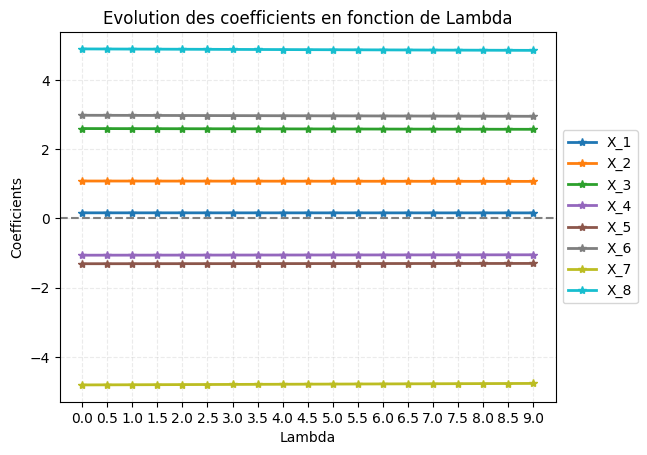

In [24]:
Regul.Visualization_Shrinking(penalized_coefficients_table=SummaryCoefRidge)

## Fonction relative aux variables sélectionnées

In [25]:
# Fonction pour sélectionner les coefficients de régression
VariablesSelected = Predictors.columns.tolist()
AlphaValueSelected = '0.5'

In [26]:
ResidualsPredicted = Regul.Predict(penalized_coefficients_table=SummaryCoefRidge,
                            variables_selected = VariablesSelected,
                            alpha_value = AlphaValueSelected,
                            true_target = Target,
                            predictors = Predictors,
                            purpose = "predicting")
print(ResidualsPredicted)

[[ 9.65803438e+00]
 [ 1.10933009e+01]
 [ 7.01937309e+00]
 [-5.93342044e-01]
 [ 6.94601730e+00]
 [ 2.45759071e+00]
 [ 5.71035210e+00]
 [ 7.60422030e+00]
 [-1.11634387e+00]
 [ 1.59308535e+01]
 [ 5.34555257e+00]
 [-2.07450695e-01]
 [ 1.30181664e+01]
 [ 4.32544268e+00]
 [ 1.15536275e+01]
 [ 1.25235108e+01]
 [ 7.54943704e-01]
 [ 1.28373513e+00]
 [ 6.25911658e+00]
 [ 8.01618165e+00]
 [ 1.28793541e+01]
 [ 3.52732367e+00]
 [ 1.54089211e+00]
 [ 1.08325006e+01]
 [ 8.16532954e+00]
 [-9.20580860e+00]
 [ 7.16546345e+00]
 [-1.98220299e+00]
 [ 7.15835679e-01]
 [-4.18208199e+00]
 [-2.43703189e+00]
 [ 9.06826670e+00]
 [ 2.57756090e+00]
 [ 9.51672360e+00]
 [-1.52442167e+00]
 [ 1.08883796e+01]
 [ 4.73061004e+00]
 [ 7.93027377e+00]
 [ 1.06323483e+01]
 [ 2.37698924e+00]
 [ 1.26892144e+01]
 [-3.55596365e-01]
 [ 8.76208742e+00]
 [ 2.04052703e+00]
 [ 9.63286928e+00]
 [-7.10153318e+00]
 [ 5.92997725e+00]
 [ 7.52478132e+00]
 [ 4.83783408e+00]
 [ 1.34473567e+00]
 [ 9.43949689e+00]
 [ 1.26192408e+01]
 [ 1.1149169

In [27]:
# Fonction pour réaliser des prévisions
TargetPredicted = Regul.Predict(penalized_coefficients_table=SummaryCoefRidge,
                            variables_selected = VariablesSelected,
                            alpha_value = AlphaValueSelected,
                            true_target = Target,
                            predictors = Predictors,
                            purpose = "residuals")
print(TargetPredicted)

[[1.29835293e+02]
 [2.20218581e+02]
 [1.72437366e+02]
 [1.65981928e+01]
 [9.54071800e+01]
 [1.01505036e+02]
 [5.41158624e+01]
 [7.96580781e+01]
 [6.21789418e+01]
 [8.64177224e+01]
 [1.46960055e+02]
 [1.12340443e+01]
 [4.04958579e+02]
 [2.37250736e+02]
 [1.59566643e+02]
 [5.34881557e+01]
 [1.22422162e+02]
 [8.47571403e+01]
 [1.35799003e+02]
 [6.82180483e+01]
 [1.88492600e+02]
 [1.09742919e+02]
 [3.01739348e+01]
 [4.07708766e+02]
 [1.25648157e+02]
 [4.06901800e+01]
 [1.03741827e+02]
 [2.07946582e+01]
 [6.47484908e+01]
 [1.12978121e+02]
 [6.31168142e+01]
 [1.89176359e+02]
 [2.22620723e+02]
 [1.38467572e+02]
 [5.42532750e+01]
 [2.31162045e+02]
 [1.16580567e+02]
 [3.69099392e+02]
 [2.17900762e+01]
 [4.07543169e+01]
 [1.64908912e+02]
 [6.28364875e+01]
 [3.34595915e+02]
 [1.76709355e+02]
 [9.76006143e+01]
 [7.22766583e+00]
 [7.01435414e+01]
 [1.53749422e+02]
 [3.70997725e+02]
 [2.01811568e+02]
 [1.51307880e+02]
 [1.52358373e+02]
 [4.45717056e+02]
 [2.31691344e+02]
 [1.19193139e+02]
 [1.038464

In [28]:
# Fonction pour réaliser des prévisions
RidgeRss = Regul.Predict(penalized_coefficients_table=SummaryCoefRidge,
                            variables_selected = VariablesSelected,
                            alpha_value = AlphaValueSelected,
                            true_target = Target,
                            predictors = Predictors,
                            purpose = "residuals_of_square")
print(RidgeRss)

144266.52160429116


In [282]:
'''
rss_complete_ridge = Regul.Residual_Sum_Square_On_Estimated_Coefficients_Framed(df_coefficient_estimated=df_coef_estimated_framed_ridge,
                                                                                Estimated_Coefficients_init=list_coefficients_ridge,
                                                                                Obs_True=Target,
                                                                                Inputs=Predictors,
                                                                                Intercept=0)

df_coef_estimated_framed_ridge.head(5)
'''

'\nrss_complete_ridge = Regul.Residual_Sum_Square_On_Estimated_Coefficients_Framed(df_coefficient_estimated=df_coef_estimated_framed_ridge,\n                                                                                Estimated_Coefficients_init=list_coefficients_ridge,\n                                                                                Obs_True=Target,\n                                                                                Inputs=Predictors,\n                                                                                Intercept=0)\n\ndf_coef_estimated_framed_ridge.head(5)\n'

In [29]:
PredictorsComplete = Predictors_scaled.copy()
PredictorsComplete['Y_actual']=Target
PredictorsComplete['Y_pred']=TargetPredicted
PredictorsComplete['RSS']=ResidualsPredicted
PredictorsComplete.head(5)

,X_1,X_2,X_3,X_4,X_5,X_6,X_7,X_8,Y_actual,Y_pred,RSS
0,-0.068502,0.524174,0.115548,0.066917,0.249847,-0.238106,-1.299418,-0.124555,21.052563,129.835293,9.658034
1,-1.954374,0.725855,0.510812,0.011614,0.801804,0.568113,-0.311616,0.637878,25.933064,220.218581,11.093301
2,0.408670,0.784697,-2.073242,0.592626,-1.811534,1.291777,-0.429319,-0.018216,20.150914,172.437366,7.019373
3,-2.092237,0.007882,0.616834,-0.296293,2.097686,1.376918,2.505163,-1.086148,3.480746,16.598193,-0.593342
4,0.884883,0.139726,1.166518,-0.056768,1.185401,-0.314296,0.257783,0.217854,16.713677,95.407180,6.946017


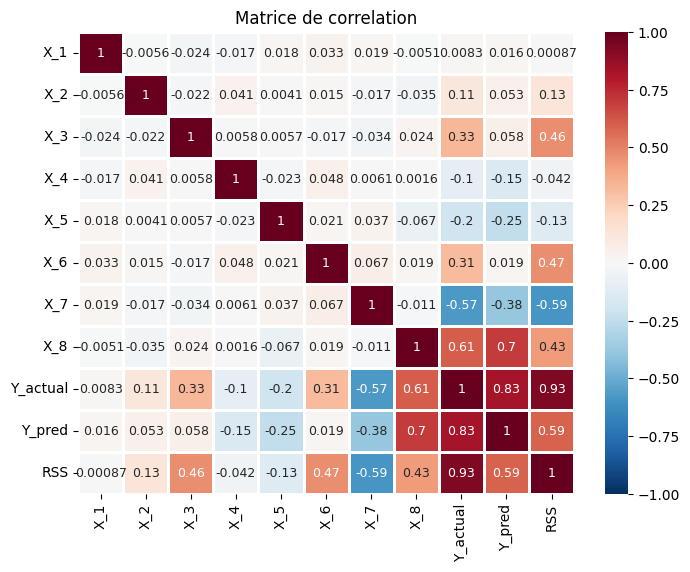

In [30]:
plt.figure(figsize=(8,6))
TarPred.Visualization(data_simulated=PredictorsComplete, figure="correlation_matrix")

<Axes: xlabel='X_6', ylabel='X_7'>

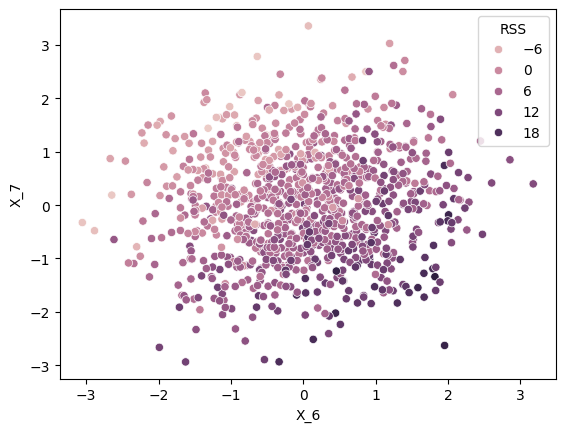

In [31]:
sns.scatterplot(data=PredictorsComplete, x='X_6', y='X_7', hue='RSS')

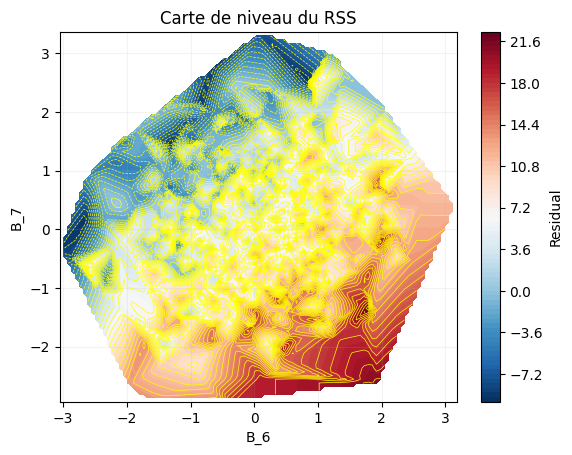

In [32]:
Regul.gradient_residual_plot(data_simulated_coefficients=PredictorsComplete, var_1='X_6', var_2='X_7', residual='RSS', model='ridge')

In [34]:
def Vizualisation_Shrinking_Circle(penalized_coefficients_table,
                                    variables_selected,
                                   alpha_value):

    from matplotlib.patches import Ellipse, Circle
    import matplotlib.pyplot as plt
    fig, ax = plt.subplots()

    # Filtre MCO
    variables_filter = penalized_coefficients_table['Variables'].isin(variables_selected)

    # coefficients MCO
    mco_coefficients = penalized_coefficients_table.loc[variables_filter, '0.0'].tolist()

    # coefficients MCO
    penalized_coefficients = penalized_coefficients_table.loc[variables_filter, alpha_value]

    # Ellipses
    angle_params = 125 # 47

    Ellipse3 = Ellipse(xy=(mco_coefficients[0], mco_coefficients[1]), width=11, height=5, angle=angle_params, fill=True, fc='orange', ec='black', alpha=0.50)
    ax.add_patch(Ellipse3)

    Ellipse2 = Ellipse(xy=(mco_coefficients[0], mco_coefficients[1]), width=8, height=3, angle=angle_params, fill=True, fc='orange', ec='black', alpha=0.25)
    ax.add_patch(Ellipse2)

    Ellipse1 = Ellipse(xy=(mco_coefficients[0], mco_coefficients[1]), width=5, height=2, angle=angle_params, fill=True, fc='orange', ec='orange', alpha=1)
    ax.add_patch(Ellipse1)

    # Cercle
    circle_cy = [0,0]

    radius_value = np.square(penalized_coefficients[0]**2+penalized_coefficients[1]**2)

    Circle1 = Circle(xy=(circle_cy[0], circle_cy[1]), radius=radius_value, color="lightsteelblue")
    ax.add_patch(Circle1)

    plt.xlim([-10,10])
    plt.ylim([-10,10])

    ax.annotate("",
                xy=(0, -10), xycoords='data',
                xytext=(0, 10), textcoords='data',
                arrowprops=dict(arrowstyle="<->",
                                connectionstyle="arc3", color='k', lw=1))

    ax.annotate("",
                xy=(-10, 0), xycoords='data',
                xytext=(10, 0), textcoords='data',
                arrowprops=dict(arrowstyle="<->",
                                connectionstyle="arc3", color='k', lw=1))

    plt.xlabel(f"{variables_selected[0]}")
    plt.ylabel(f"{variables_selected[1]}")



    plt.plot(mco_coefficients[0],mco_coefficients[1], 'k.')
    plt.text(mco_coefficients[0],mco_coefficients[1], "beta")
    plt.grid(True, alpha=0.15, linestyle='--')
    plt.show()


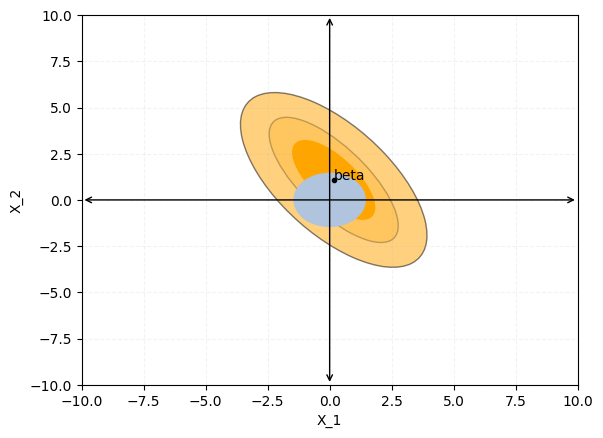

In [35]:
Vizualisation_Shrinking_Circle(penalized_coefficients_table=SummaryCoefRidge,
                               variables_selected=['X_1', 'X_2'],
                               alpha_value='0.5')

# ----------------------
# ----------------------
# ----------------------

In [31]:
TrueCoefficients

[0.69, 1.41, 2.73, -2.84, -3, 3.14, -7, 11]

In [36]:
# Fonction pour calculer la surface de la somme des carrés des résidus
def surface_residual_plot(start, stop, number_simulated, predictors, target):

    number_features = predictors.shape[1] # Nombre de lignes
    simulated_penalized_coefficients = np.zeros(shape=(number_simulated, number_features))
    interval_complete = np.linspace(start=start, stop=stop, num=number_simulated)

    list_residuals_sum_squares = []

    for i in range(0, simulated_penalized_coefficients.shape[0]):
        simulated_penalized_coefficients[i,:] = interval_complete[i]
        vector_penalized_coefficients = simulated_penalized_coefficients[i,:]#reshape(1,number_features)
        input_array = predictors.values
        target_predicted = input_array @ vector_penalized_coefficients
        residuals_sum_squares = np.sum((target - target_predicted)**2)
        list_residuals_sum_squares.append(residuals_sum_squares)

    df = pd.DataFrame(simulated_penalized_coefficients, columns=predictors.columns)
    df['RSS'] = list_residuals_sum_squares
    return df
    #print(simulated_penalized_coefficients[:,i])
    #print(penalized_coefficient.shape)
    #print(pd.DataFrame(simulated_penalized_coefficients, columns=predictors.columns))

linear_simulated_coefficients = surface_residual_plot(start=-1500, stop=1500, number_simulated=200, predictors=Predictors, target=Target)
linear_simulated_coefficients.head(5)

,X_1,X_2,X_3,X_4,X_5,X_6,X_7,X_8,RSS
0,-1500.000000,-1500.000000,-1500.000000,-1500.000000,-1500.000000,-1500.000000,-1500.000000,-1500.000000,3.788868e+13
1,-1484.924623,-1484.924623,-1484.924623,-1484.924623,-1484.924623,-1484.924623,-1484.924623,-1484.924623,3.713281e+13
2,-1469.849246,-1469.849246,-1469.849246,-1469.849246,-1469.849246,-1469.849246,-1469.849246,-1469.849246,3.638454e+13
3,-1454.773869,-1454.773869,-1454.773869,-1454.773869,-1454.773869,-1454.773869,-1454.773869,-1454.773869,3.564389e+13
4,-1439.698492,-1439.698492,-1439.698492,-1439.698492,-1439.698492,-1439.698492,-1439.698492,-1439.698492,3.491086e+13


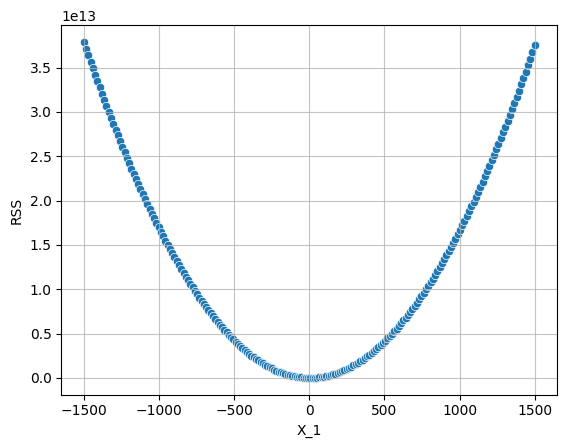

In [37]:
sns.scatterplot(data=linear_simulated_coefficients, x='X_1', y='RSS')
plt.grid(True)

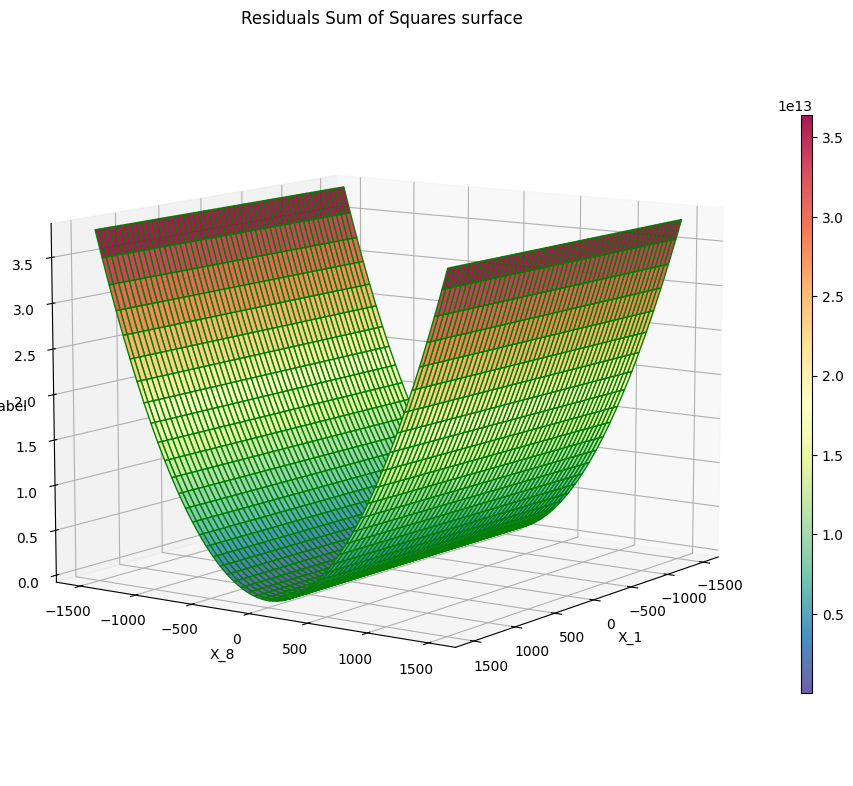

In [38]:
fig = plt.figure(figsize=(12,15))
ax = fig.add_subplot(111, projection='3d')
var1 = 'X_1'
var2 = 'X_8'

ax.zaxis.set_rotate_label(False)
ax.view_init(10,35)
x_1 = linear_simulated_coefficients[var1].values
x_2 = linear_simulated_coefficients[var2].values
rss = linear_simulated_coefficients['RSS'].values

X1, X2 = np.meshgrid(x_1, x_2)
RSS, RSS = np.meshgrid(rss, rss)

surf = ax.plot_surface(X1, X2, RSS, cmap='Spectral_r', edgecolor='green', alpha=0.9) #
fig.colorbar(surf, shrink=0.5, aspect=50)
ax.set_xlabel(f'{var1}')
ax.set_ylabel(f'{var2}')
ax.set_zlabel('RSS Label')
plt.grid(True)
plt.title("Residuals Sum of Squares surface")
plt.show()

In [39]:
housing = pd.read_csv('housing.csv')
target_house = housing['median_income']
predictors_house = housing.drop(['median_income', 'ocean_proximity'], axis=1)

In [40]:
california_simulated = surface_residual_plot(start=-1500, stop=1500, number_simulated=200, predictors=predictors_house, target=target_house)
california_simulated.head(5)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_house_value,RSS
0,-1500.000000,-1500.000000,-1500.000000,-1500.000000,-1500.000000,-1500.000000,-1500.000000,-1500.000000,2.681074e+21
1,-1484.924623,-1484.924623,-1484.924623,-1484.924623,-1484.924623,-1484.924623,-1484.924623,-1484.924623,2.627454e+21
2,-1469.849246,-1469.849246,-1469.849246,-1469.849246,-1469.849246,-1469.849246,-1469.849246,-1469.849246,2.574376e+21
3,-1454.773869,-1454.773869,-1454.773869,-1454.773869,-1454.773869,-1454.773869,-1454.773869,-1454.773869,2.521839e+21
4,-1439.698492,-1439.698492,-1439.698492,-1439.698492,-1439.698492,-1439.698492,-1439.698492,-1439.698492,2.469844e+21


In [41]:
min_filter = california_simulated['RSS'].min()
california_simulated.loc[california_simulated['RSS']==min_filter,:]


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_house_value,RSS
100,7.537688,7.537688,7.537688,7.537688,7.537688,7.537688,7.537688,7.537688,6.770189e+16


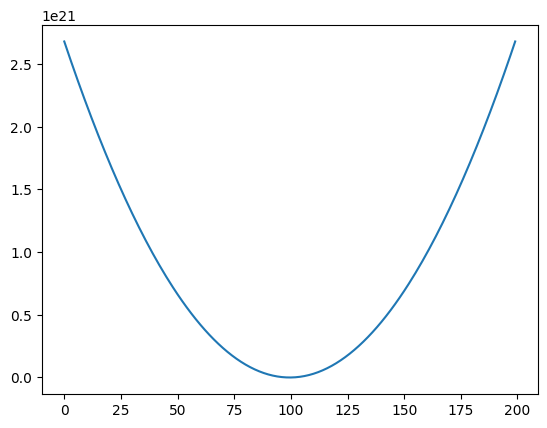

In [42]:
plt.plot(california_simulated['RSS'])

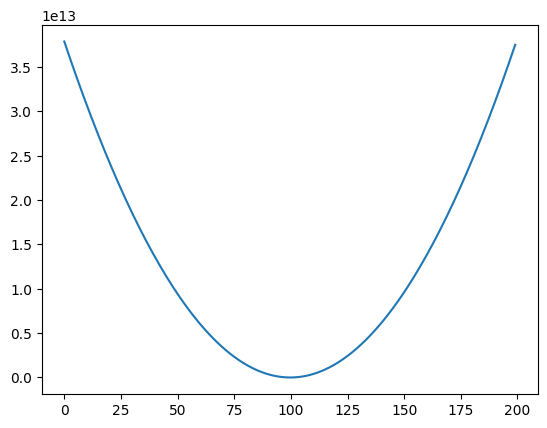

In [43]:
plt.plot(linear_simulated_coefficients['RSS'])

<Axes: xlabel='longitude', ylabel='RSS'>

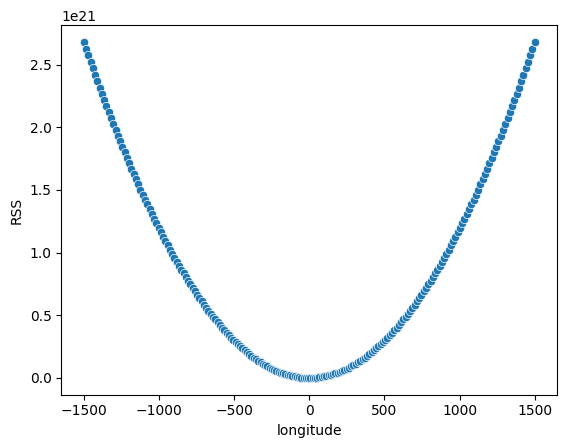

In [44]:
sns.scatterplot(data=california_simulated, x='longitude', y='RSS')

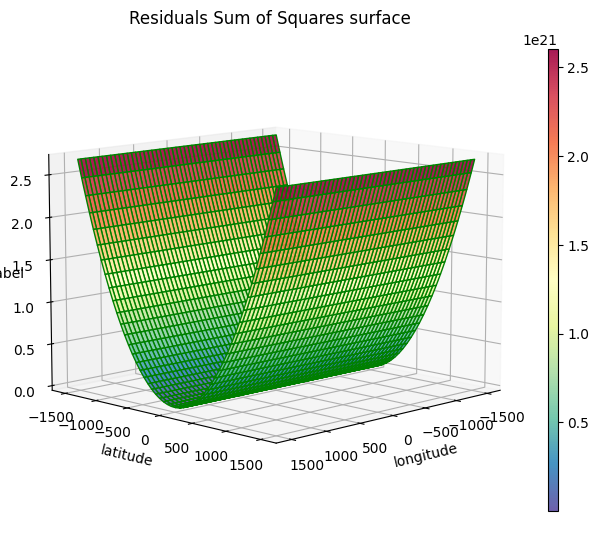

In [50]:
fig = plt.figure(figsize=(8,12))
ax = fig.add_subplot(111, projection='3d')
var1 = 'longitude'
var2 = 'latitude'

ax.zaxis.set_rotate_label(False)
ax.view_init(10, 45)
x_1 = california_simulated[var1].values
x_2 = california_simulated[var2].values
rss = california_simulated['RSS'].values

X1, X2 = np.meshgrid(x_1, x_2)
RSS, RSS = np.meshgrid(rss, rss)

surf = ax.plot_surface(X1, X2, RSS, cmap='Spectral_r', edgecolor='green', alpha=0.9) #
fig.colorbar(surf, shrink=0.5, aspect=50)
ax.set_xlabel(f'{var1}')
ax.set_ylabel(f'{var2}')
ax.set_zlabel('RSS Label')
plt.grid(True)
plt.title("Residuals Sum of Squares surface")
plt.show()

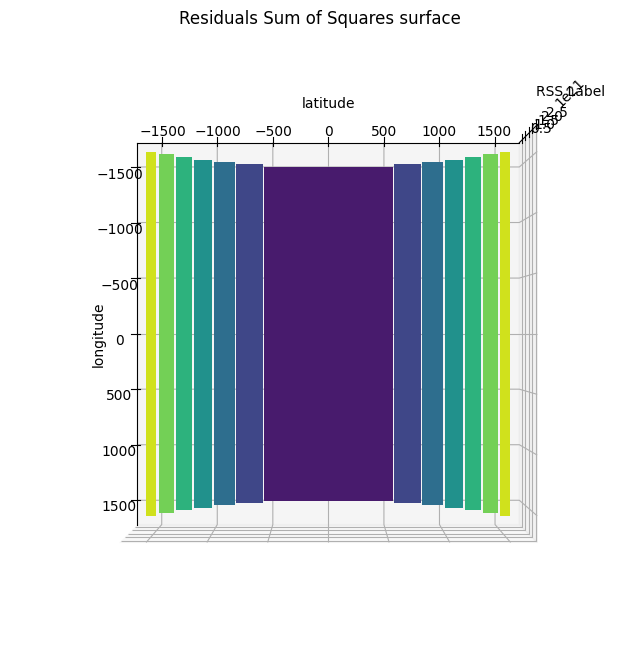

In [57]:
fig = plt.figure(figsize=(8,12))
ax = fig.add_subplot(111, projection='3d')
var1 = 'longitude'
var2 = 'latitude'

ax.zaxis.set_rotate_label(False)
ax.view_init(90,0)
x_1 = california_simulated[var1].values
x_2 = california_simulated[var2].values
rss = california_simulated['RSS'].values

X1, X2 = np.meshgrid(x_1, x_2)
RSS, RSS = np.meshgrid(rss, rss)

surf = ax.contourf(X1, X2, RSS) #cmap='Spectral_r', edgecolor='green', alpha=0.9
ax.set_xlabel(f'{var1}')
ax.set_ylabel(f'{var2}')
ax.set_zlabel('RSS Label')
plt.grid(True)
plt.title("Residuals Sum of Squares surface")
plt.show()

In [ ]:
#Regul.gradient_residual_plot(data_simulated_coefficients=linear_simulated_coefficients, var_1='X_1', var_2='X_2', residual='RSS', model='ridge')

Text(0.5, 0.92, '$J(w,b)$\n [You can rotate this figure]')

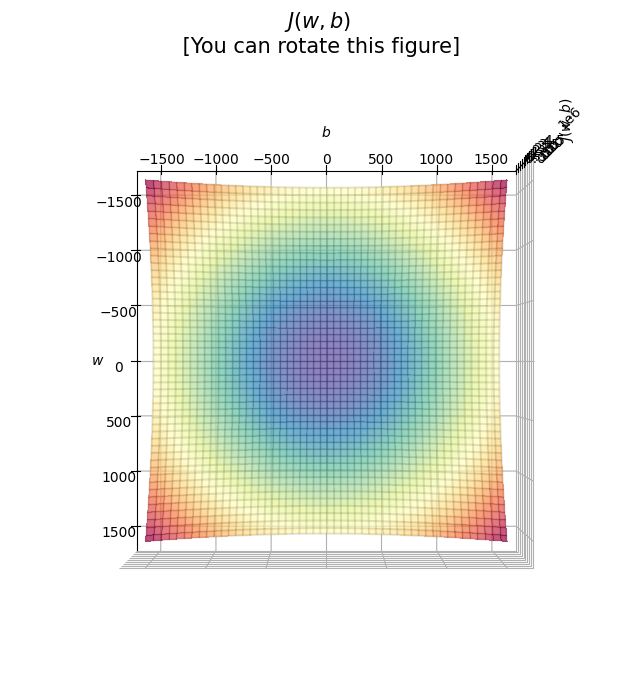

In [59]:
#Plot configuration

fig = plt.figure(figsize=(8,8))

ax = fig.add_subplot(111, projection='3d')
ax.xaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.yaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_pane_color((1.0, 1.0, 1.0, 0.0))
ax.zaxis.set_rotate_label(False)
ax.view_init(90, 0)

w =  linear_simulated_coefficients['X_2'].values # np.linspace(-20, 20, 100)
b =  linear_simulated_coefficients['X_2'].values # np.linspace(-20, 20, 100)
#Get the z value for a bowl-shaped cost function
z=np.zeros((len(w), len(b)))
j=0
for x in w:
    i=0
    for y in b:
        z[i,j] = x**2 + y**2
        i+=1
    j+=1
W, B = np.meshgrid(w, b)


#Create the 3D surface plot of the bowl-shaped cost function
ax.plot_surface(W, B, z, cmap = "Spectral_r", alpha=0.7, antialiased=False)
ax.plot_wireframe(W, B, z, color='k', alpha=0.1)
ax.set_xlabel("$w$")
ax.set_ylabel("$b$")
ax.set_zlabel("$J(w,b)$", rotation=90)
ax.set_title("$J(w,b)$\n [You can rotate this figure]", size=15)


In [191]:
# Fonction pour simuler les coefficiens de régression estimés selon une loi uniforme en fonction des variables d'entrée sélectionnées.
def Simulation_Penalized_Coefficients(born_inf, born_sup, step, number_simulated_penalized_coefficients, model):

    data_simulated_coefficients = pd.DataFrame()

    # Commentaire : Il se peut que certains coéfficients de la régression lasso soient nuls, par conséquent, il est préférable de mettre un garde-fou.
    for enum, i in enumerate(penalized_coefficients_init):
        if i != 0:
            if model == "ridge":
                interval_complete = np.random.normal(true_coefficients[enum], alpha_value, number_simulated_penalized_coefficients)
            elif model == "lasso":
                interval_complete = np.random.laplace(true_coefficients[enum], alpha_value,
                                                      number_simulated_penalized_coefficients)
            else:
                raise ValueError("La valeurs associée à l'argument 'Model' est incorrect.")
            data_simulated_coefficients[f"X_{enum + 1}"] = interval_complete
            print(f"\n Fin de l'encadrement du coefficient estimé de la variable X_{enum + 1}\n -----------")

    for line_index in data_simulated_coefficients.index:
        beta_penalized_simulated = data_simulated_coefficients.iloc[line_index, :]
        beta_penalized_simulated_array = np.array(beta_penalized_simulated.values)
        y_simulated = input_array @ beta_penalized_simulated_array
        residuals_simulated = np.sum((output - y_simulated) ** 2)
        list_residual_sum_square.append(residuals_simulated)
        print(residual)
        print(f"Somme des carrés des residus du Cycle : {line} \n-----------")
    data_simulated_coefficients['RSS'] = list_residual_sum_square
    return data_simulated_coefficients

In [192]:
list_estimators_names = summary_coef_ridge['Variables']
list_estimators_mco_values = RegMCO.coef_
list_estimators_ridge_values = summary_coef_ridge[alpha_selected]
df_barplot = pd.DataFrame({
    'variables' : list_estimators_names,
    'true_coefficients': Coefs_B,
    'mco': list_estimators_mco_values[0],
    'ridge': list_estimators_ridge_values,
})
df_barplot

NameError: name 'summary_coef_ridge' is not defined

NameError: name 'df_barplot' is not defined

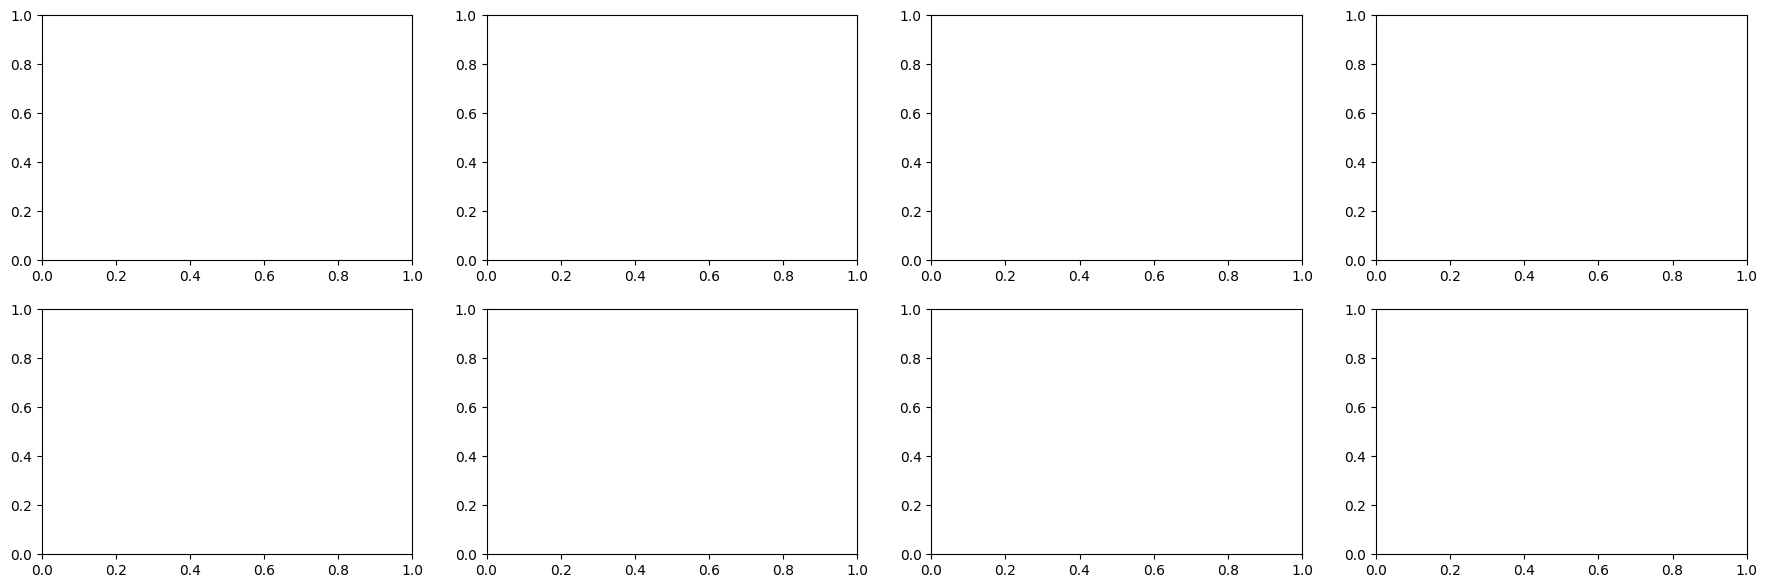

In [189]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(nrows=2, ncols=4, figsize=(22, 7))
axs = ax.flatten()

for i, estimators in enumerate(df_barplot['variables']):
    estimators_names = list(df_barplot.columns[1:])
    estimators_values = df_barplot.loc[df_barplot['variables'].isin([estimators]),estimators_names].values[0]
    axs[i].bar(estimators_names, estimators_values, color = 'lightsteelblue', align='center',  capsize=10)
    axs[i].plot(estimators_names, estimators_values, color='darkred', marker='*', linewidth=2, ms=10)
    axs[i].set_xlabel(f'{estimators_names[0]}')
    axs[i].set_ylabel(f"valeur")
    axs[i].grid(True)
plt.show()

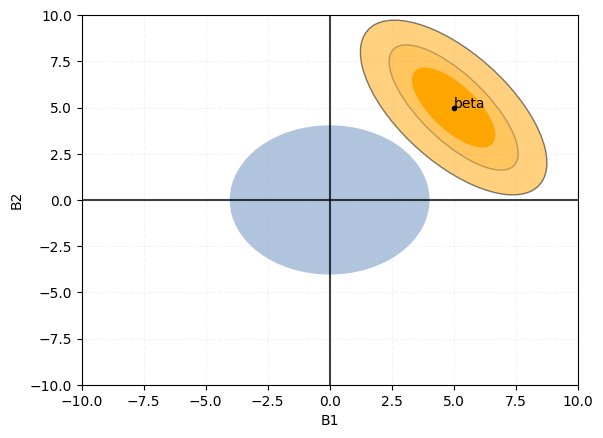